In [1]:
import qubx

%qubxd

%load_ext autoreload
%autoreload 2

from typing import cast
import numpy as np
import pandas as pd
import asyncio
from pathlib import Path
from qubx.core.lookups import lookup
from qubx.connectors.ccxt.factory import get_ccxt_exchange
from qubx import logger, QubxLogConfig
from qubx.core.interfaces import IStrategy, IStrategyContext, BaseErrorEvent, IStrategyInitializer
from qubx.utils.runner.runner import (
    run_strategy,
    StrategyConfig,
    AccountConfigurationManager,
    ExchangeConfig,
    LoggingConfig,
)
from qubx.utils.runner.configs import LiveConfig, StorageConfig
from qubx.core.basics import DataType, MarketEvent
from qubx.utils.charting.lookinglass import LookingGlass

QubxLogConfig.set_log_level("DEBUG")


⠀⠀⡰⡖⠒⠒⢒⢦⠀⠀   
⠀⢠⠃⠈⢆⣀⣎⣀⣱⡀  QUBX | Quantitative Backtesting Environment 
⠀⢳⠒⠒⡞⠚⡄⠀⡰⠁         (c) 2025, ver. 1.0.0.dev6
⠀⠀⠱⣜⣀⣀⣈⣦⠃⠀⠀⠀ 
        


2026-03-12 14:06:24.545 [ 🐞 ] (misc) uvloop installed successfully
2026-03-12 14:06:24.548 [ 🐞 ] (runner) Shared event loop started in background thread
2026-03-12 14:06:24.548 [ 🐞 ] (ntp) NTP offset controller thread is started


## 1.0 Check if instruments are available

In [2]:
instruments = lookup.find_instruments("OKX.F", market_type="SWAP")
len(instruments)

469

In [3]:
instruments[0].info()


┌─────────────────────────────┐
│ Instrument Information      │
└─────────────────────────────┘
  Exchange:          OKX.F
  Symbol:            BTCUSDT
  Market Type:       SWAP
  Base:              BTC
  Quote:             USDT
  Exchange Symbol:   BTC-USDT-SWAP
  Tick Size:         0.1
  Lot Size:          0.01
  Min Size:          0.01
  Min Notional:      0.0
  Initial Margin:    0.0
  Maint. Margin:     0.0
  Onboard Date:      2019-12-04T00:00:00
  Delist Date:       None



## 2.0 Run simple strategy without blocking

In [4]:
class TestStrategy(IStrategy):
    def on_init(self, initializer: IStrategyInitializer):
        initializer.set_base_subscription(DataType.OHLC["1h"])
        initializer.set_subscription_warmup({DataType.OHLC["1h"]: "1d"})

    def on_market_data(self, ctx: IStrategyContext, data: MarketEvent):
        pass

    def on_error(self, ctx: IStrategyContext, error: BaseErrorEvent) -> None:
        logger.error(f"Error: {error}")

    def on_stop(self, ctx: IStrategyContext):
        logger.info("Stopping test strategy")

In [ ]:
ctx = run_strategy(
    config=StrategyConfig(
        name="TestStrategy",
        strategy=TestStrategy,
        aux=StorageConfig(storage="ccxt", args={"max_history": "10d"}),
        live=LiveConfig(
            exchanges={
                "OKX.F": ExchangeConfig(
                    connector="ccxt",
                    universe=["BTCUSDT", "ETHUSDT"],
                )
            },
            logging=LoggingConfig(
                logger="InMemoryLogsWriter",
                position_interval="10s",
                portfolio_interval="1m",
                heartbeat_interval="10m",
            ),
        ),
    ),
    account_manager=AccountConfigurationManager(),
    paper=True,
    blocking=False,
)

2026-03-12 13:09:39.276 [🐞] (runner) Setup InMemoryLogsWriter logger...
2026-03-12 13:09:39.277 [🐞] (exchange_manager) Registered recreation callback for OKX.F
2026-03-12 13:09:39.278 [ℹ️] (data) OKX.F Initialized
2026-03-12 13:09:39.279 [ℹ️] (runner) - Strategy: TestStrategy
- Mode: paper
- Parameters: {}
2026-03-12 13:09:39.284 [ℹ️] (warmup_service) OKX.F Starting subscription warmup for 2 items


2026-03-12 13:09:41.308 [🐞] (ohlc) OKX.F OKX.F:SWAP:BTCUSDT: loaded 24 1h bars
2026-03-12 13:09:41.588 [🐞] (ohlc) OKX.F OKX.F:SWAP:ETHUSDT: loaded 24 1h bars
2026-03-12 13:09:41.590 [ℹ️] (warmup_service) OKX.F Warmup completed successfully
2026-03-12 13:09:41.591 [ℹ️] (connection_manager) OKX.F Listening to ohlc(1h):2:cb8f7642-f96d-4e0f-940d-507d15f88413
2026-03-12 13:09:41.592 [ℹ️] (context) [StrategyContext] :: Start processing market data
2026-03-12 13:09:41.593 [ℹ️] (context) [StrategyContext] :: strategy is started in thread
2026-03-12 13:09:41.596 [ℹ️] (processing) Waiting for all instruments (0/2 ready). Missing: ['BTCUSDT', 'ETHUSDT']. Will start with partial data in 60s


2026-03-12 13:09:41.991 [ℹ️] (loggers) Heartbeat at 2026-03-12T13:00:00
2026-03-12 13:09:43.413 [ℹ️] (processing) All 2 instruments have data - strategy ready to start
2026-03-12 13:09:43.415 [🐞] (processing) [ProcessingManager] :: Invoking TestStrategy on_warmup_finished
2026-03-12 13:09:43.415 [🐞] (processing) [ProcessingManager] :: TestStrategy warmup finished completed
2026-03-12 13:09:43.515 [🐞] (processing) [ProcessingManager] :: Invoking TestStrategy on_fit
2026-03-12 13:09:43.516 [🐞] (processing) [ProcessingManager] :: TestStrategy is fitted
2026-03-12 13:10:00.349 [ℹ️] (loggers) Heartbeat at 2026-03-12T13:10:00
2026-03-12 13:10:15.376 [ℹ️] (warmup_service) OKX.F Starting subscription warmup for 5 items
2026-03-12 13:10:15.652 [🐞] (ohlc) OKX.F OKX.F:SWAP:XRPUSDT: loaded 24 1h bars
2026-03-12 13:10:15.908 [🐞] (ohlc) OKX.F OKX.F:SWAP:SOLUSDT: loaded 24 1h bars
2026-03-12 13:10:16.164 [🐞] (ohlc) OKX.F OKX.F:SWAP:DOGEUSDT: loaded 24 1h bars
2026-03-12 13:10:16.480 [🐞] (ohlc) OKX.F 

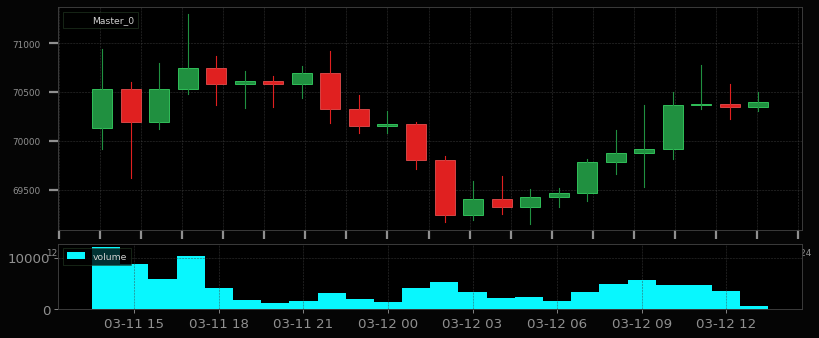

In [7]:
ohlc = ctx.ohlc(ctx.query_instrument("BTCUSDT")).pd()

LookingGlass(
    ohlc,
    {
        "volume": ["bars", ohlc["volume"]],
    },
    backend="mpl",
).look()

In [8]:
add_symbols = ["BTCUSDT", "ETHUSDT", "XRPUSDT", "SOLUSDT", "DOGEUSDT", "ADAUSDT", "LINKUSDT"]
add_instruments = [ctx.query_instrument(symbol) for symbol in add_symbols]
print(add_instruments)
ctx.set_universe(add_instruments)

[OKX.F:SWAP:BTCUSDT, OKX.F:SWAP:ETHUSDT, OKX.F:SWAP:XRPUSDT, OKX.F:SWAP:SOLUSDT, OKX.F:SWAP:DOGEUSDT, OKX.F:SWAP:ADAUSDT, OKX.F:SWAP:LINKUSDT]


In [9]:
ctx.subscribe(DataType.ORDERBOOK[0.01, 100])

## 2.0 Plot the orderbook

In [10]:
symbol = "BTCUSDT"
instrument = ctx.query_instrument(symbol)
ob = ctx.get_cached_market_data(instrument, DataType.ORDERBOOK)
ob.pd()

,top_bid,top_ask,tick_size,bids,asks
time,,,,,
2026-03-12 13:10:28.502,70411.0,70411.1,7.0,"[1433.429999999999, 801.2699999999996, 1303.65...","[524.2200000000001, 550.9599999999999, 1131.24..."
2026-03-12 13:10:29.202,70411.0,70411.1,7.0,"[1434.7199999999991, 800.9699999999997, 1303.6...","[471.7100000000002, 550.2499999999999, 1127.84..."
2026-03-12 13:10:29.302,70411.0,70411.1,7.0,"[1434.729999999999, 800.9699999999997, 1303.63...","[471.7200000000002, 550.2499999999999, 1127.84..."
2026-03-12 13:10:29.402,70411.0,70411.1,7.0,"[1441.0699999999993, 910.8499999999997, 1342.7...","[186.71999999999994, 399.03000000000003, 1143...."
2026-03-12 13:10:29.502,70411.0,70411.1,7.0,"[1492.6399999999992, 941.9599999999998, 1370.7...","[153.05, 395.40000000000003, 1145.73, 1595.01,..."
...,...,...,...,...,...
2026-03-12 13:10:48.202,70388.3,70388.4,7.0,"[1217.2799999999997, 1390.0999999999995, 1531....","[417.28, 579.0899999999998, 1214.9199999999998..."
2026-03-12 13:10:48.302,70388.3,70388.4,7.0,"[1286.6399999999996, 1468.9499999999994, 1452....","[312.94, 601.8099999999998, 1205.9699999999998..."
2026-03-12 13:10:49.502,70388.3,70388.4,7.0,"[1213.2499999999995, 1410.0999999999995, 1531....","[392.27000000000004, 606.1099999999998, 1168.6..."


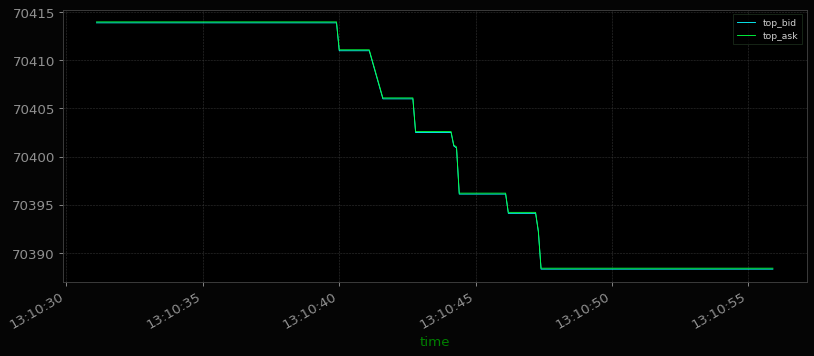

In [11]:
ob.pd()[["top_bid", "top_ask"]].iloc[-100:].plot();

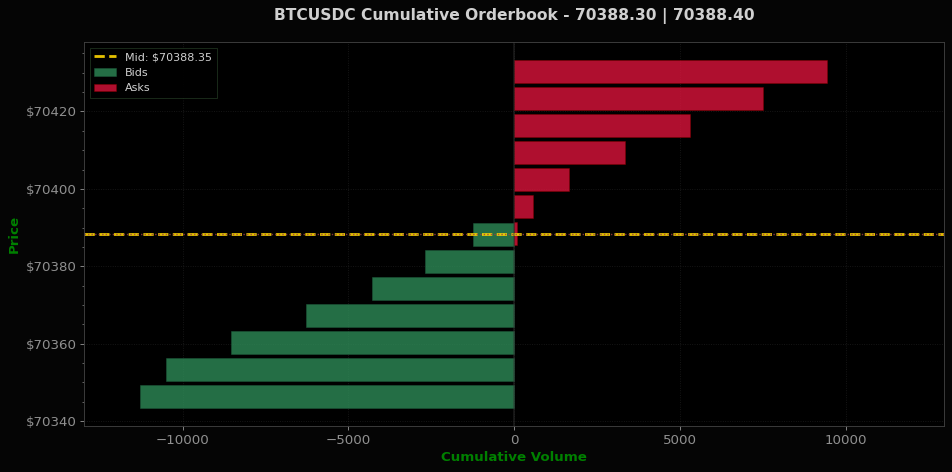

In [12]:
import matplotlib.pyplot as plt
from qubx.utils.charting.orderbook import plot_orderbook, plot_orderbook_depth, plot_orderbook_comparison

# Plot regular orderbook
# fig1, ax1 = plot_orderbook(ob, cumulative=False, max_levels=15,
#                           title=f"BTCUSDC Orderbook - {ob.top_bid:.2f} | {ob.top_ask:.2f}")
# plt.show()

# Plot cumulative orderbook
fig2, ax2 = plot_orderbook(
    ob[0],
    cumulative=True,
    max_levels=20,
    title=f"BTCUSDC Cumulative Orderbook - {ob[0].top_bid:.2f} | {ob[0].top_ask:.2f}",
    figsize=(12, 6),
)
plt.show()

# Plot depth chart
# fig3, ax3 = plot_orderbook_depth(ob, max_levels=15,
#                                 title=f"BTCUSDC Depth Chart - {ob.top_bid:.2f} | {ob.top_ask:.2f}")
# plt.show()

## 4.0 Orderbook Time Evolution Comparison

Let's compare how the orderbook has evolved over the last 10 snapshots.

In [13]:
obs = ctx.get_cached_market_data(instrument, DataType.ORDERBOOK)[:50]
len(obs)

50

Comparing 5 orderbook snapshots
Actual timestamps: ['13:11:17.502', '13:11:15.102', '13:11:12.902', '13:11:09.602', '13:11:08.102']
Labels: ['Now', 'T-2s', 'T-4s', 'T-7s', 'T-9s']


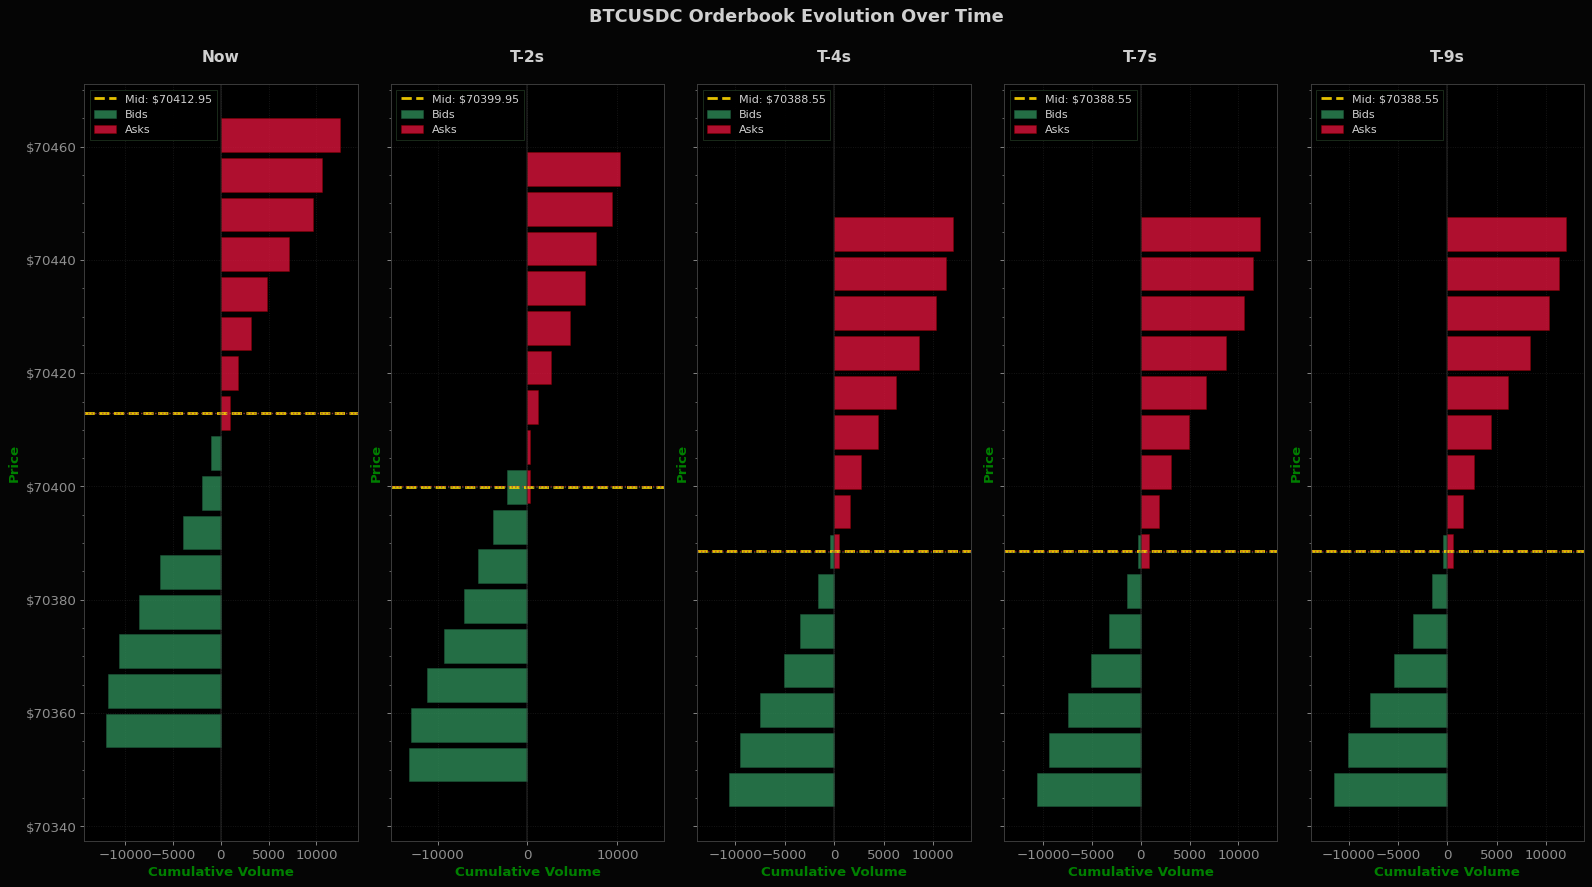

In [14]:
# Compare the evolution of orderbooks over time
# Let's take every 10th orderbook to avoid overcrowding (10 total)
comparison_obs = obs[::10]  # Take every 10th orderbook

# Create proper time labels using actual timestamps
timestamps = [pd.Timestamp(ob.time) for ob in comparison_obs]
current_time = pd.Timestamp(obs[0].time)
labels = []

for ts in timestamps:
    seconds_ago = int((current_time - ts).total_seconds())
    if seconds_ago == 0:
        labels.append("Now")
    elif seconds_ago < 60:
        labels.append(f"T-{seconds_ago}s")
    else:
        minutes_ago = seconds_ago // 60
        labels.append(f"T-{minutes_ago}m{seconds_ago % 60}s")

print(f"Comparing {len(comparison_obs)} orderbook snapshots")
print("Actual timestamps:", [ts.strftime("%H:%M:%S.%f")[:-3] for ts in timestamps])
print("Labels:", labels)

# Create comparison plot
fig, axes = plot_orderbook_comparison(comparison_obs, labels=labels, cumulative=True, figsize=(20, 12))
plt.suptitle("BTCUSDC Orderbook Evolution Over Time", fontsize=16, fontweight="bold", y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [15]:
ctx.stop()